# HDT 4: Regresión Logística y Métricas

**Ciencia de Datos, Sección A** · Asignada: jueves 17 de septiembre · **Entrega: martes 22 de septiembre, 23:59**

**Nombre:** _Juan David Contreras_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semilla fija y split fijo): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Una empresa de internet residencial quiere saber qué clientes van a cancelar. Historial de 1,200 clientes: `mensualidad` (quetzales al mes), `meses` (antigüedad como cliente), `reclamos` (en el último año) y `cancelo` (1 = canceló el servicio). Es el mismo tipo de problema que la mora de la sesión 14, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [2]:
rng = np.random.default_rng(9)
n = 1200
mensualidad = rng.normal(350, 90, n).clip(150, 700).round(0)
meses = rng.integers(1, 61, n)
reclamos = np.minimum(rng.poisson(0.8, n), 6)

riesgo = -1.1 + 0.006 * (mensualidad - 350) - 0.06 * meses + 0.9 * reclamos
cancelo = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"mensualidad": mensualidad, "meses": meses,
                   "reclamos": reclamos, "cancelo": cancelo})
print("clientes:", len(df), "| fracción que canceló:", df["cancelo"].mean().round(3))
df.head()

clientes: 1200 | fracción que canceló: 0.169


,mensualidad,meses,reclamos,cancelo
0,278.0,48,0,0
1,372.0,46,0,0
2,201.0,7,0,0
3,409.0,24,2,0
4,453.0,48,3,0


## Parte A · El modelo (0.5 pt)

Regresión logística como en la sesión 14: una suma con pesos que la sigmoide convierte en una probabilidad entre 0 y 1.

### Ejercicio 1 (0.15): entrenar y leer los pesos

Entrenar el pipeline de clase (StandardScaler + LogisticRegression) sobre el split dado. Extraer el punto de partida `b` y los tres `pesos`, e imprimirlos con el nombre de su columna. Responder en un comentario: ¿qué columna protege más contra la cancelación?

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

columnas = ["mensualidad", "meses", "reclamos"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["cancelo"], test_size=0.3, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression())
modelo.fit(X_train, y_train)
b = modelo[1].intercept_[0]   
pesos = modelo[1].coef_[0]         

# imprimir b y cada peso con su columna
print("b (punto de partida):", round(b, 2))
for col, w in zip(columnas, pesos):
    print(f"  {col}: {round(w, 2)}")
# Respuesta: `meses` es la columna que más protege contra la cancelación: tiene el
# peso más negativo (-1.35), así que a más antigüedad, mucha menos probabilidad de cancelar.
# Verificación (descomentar):
assert round(b, 2) == -2.29
assert [round(w, 2) for w in pesos] == [0.64, -1.35, 0.62]

b (punto de partida): -2.29
  mensualidad: 0.64
  meses: -1.35
  reclamos: 0.62


### Ejercicio 2 (0.20): un cliente, a mano

Cliente nuevo: paga Q380, lleva 4 meses, puso 2 reclamos. Calcular su probabilidad de cancelar sin `predict_proba`: (a) escalar cada valor con `escalador.mean_` y `escalador.scale_`, (b) armar la suma `b + w1 * x1 + w2 * x2 + w3 * x3`, (c) pasarla por la sigmoide. Luego comparar contra `modelo.predict_proba`: deben coincidir.

In [4]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

cliente = pd.DataFrame({"mensualidad": [380.0], "meses": [4], "reclamos": [2]})

# el escalador es modelo[0]; sus medias y desviaciones: .mean_ y .scale_
escalador = modelo[0]
esc_cliente = (cliente[columnas].values[0] - escalador.mean_) / escalador.scale_
z = b + np.dot(pesos, esc_cliente)  
p_mano = sigmoide(z)
p_sklearn = modelo.predict_proba(cliente)[0, 1]  

print("z:", round(z, 3))
print("p_mano:", round(p_mano, 3), "| p_sklearn:", round(p_sklearn, 3))

# Verificación (descomentar):
assert round(p_mano, 3) == round(p_sklearn, 3) == 0.721

z: 0.949
p_mano: 0.721 | p_sklearn: 0.721


### Ejercicio 3 (0.15): equivocarse con confianza cuesta caro

El castigo de una predicción es `-log(p asignada a lo que realmente pasó)`. (a) Calcular el castigo para un cliente que sí canceló al que el modelo le dijo 0.99, 0.9, 0.5, 0.1 y 0.01. (b) Con `log_loss`, el castigo promedio del modelo en test contra el de un modelo tibio que le dice 0.5 a todo el mundo.

In [ ]:
from sklearn.metrics import log_loss

p_dijo = np.array([0.99, 0.9, 0.5, 0.1, 0.01])
castigos = -np.log(p_dijo)   

for p, c in zip(p_dijo, castigos):
    print(f"dijo {p} -> castigo {round(c, 2)}")

prob = modelo.predict_proba(X_test)[:, 1]     
castigo_modelo = log_loss(y_test, prob)
castigo_tibio = log_loss(y_test, np.full(len(y_test), 0.5)) 

print("castigo promedio del modelo:", round(castigo_modelo, 3))
print("castigo promedio del modelo tibio:", round(castigo_tibio, 3))

# Verificación (descomentar):
assert round(castigos[-1], 1) == 4.6
assert round(castigo_modelo, 3) == 0.347 and round(castigo_tibio, 3) == 0.693

dijo 0.99 -> castigo 0.01
dijo 0.9 -> castigo 0.11
dijo 0.5 -> castigo 0.69
dijo 0.1 -> castigo 2.3
dijo 0.01 -> castigo 4.61
castigo promedio del modelo: 0.347
castigo promedio del modelo tibio: 0.693


## Parte B · Métricas como conteos (0.5 pt)

Solo el 17% de los clientes cancela. Con clases desbalanceadas, contar aciertos engaña; contar por tipo de acierto y de error, no.

### Ejercicio 4 (0.15): el modelo perezoso

(a) La accuracy de un modelo perezoso que dice "nadie cancela". (b) La accuracy del modelo real con umbral 0.5. Ver qué tan poca ventaja aparenta tener el modelo cuando se mide con la métrica equivocada.

In [6]:
pred = (prob >= 0.5).astype(int)     # las predicciones con umbral 0.5

acc_perezoso = (y_test == 0).mean()  # fracción de y_test que es 0 ("nadie cancela")
acc_modelo = (pred == y_test).mean()

print("accuracy del modelo perezoso:", round(acc_perezoso, 3))
print("accuracy del modelo real:", round(acc_modelo, 3))

# Verificación (descomentar):
assert round(acc_perezoso, 3) == 0.833
assert round(acc_modelo, 3) == 0.869

accuracy del modelo perezoso: 0.833
accuracy del modelo real: 0.869


### Ejercicio 5 (0.20): los cuatro conteos

Con umbral 0.5, calcular los cuatro conteos y armar la tabla 2 x 2 como en clase (filas: canceló / se quedó; columnas: el modelo dijo cancela / dijo se queda).

In [7]:
TP = ((pred == 1) & (y_test == 1)).sum()   # dijo cancela y canceló
FP = ((pred == 1) & (y_test == 0)).sum()   # dijo cancela y se quedó: llamada de retención desperdiciada
FN = ((pred == 0) & (y_test == 1)).sum()   # dijo se queda y canceló: cliente perdido sin aviso
TN = ((pred == 0) & (y_test == 0)).sum()   # dijo se queda y se quedó

tabla = pd.DataFrame(
    {"dijo cancela": [TP, FP], "dijo se queda": [FN, TN]},
    index=["canceló", "se quedó"]
)
print(tabla)

# Verificación (descomentar):
assert [TP, FP, FN, TN] == [22, 9, 38, 291]
assert TP + FP + FN + TN == len(y_test)

          dijo cancela  dijo se queda
canceló             22             38
se quedó             9            291


### Ejercicio 6 (0.15): las dos preguntas del negocio

Desde los conteos, sin sklearn: precision (de las alertas, ¿cuántas eran canceladores de verdad?) y recall (de los que cancelaron, ¿a cuántos alcanzó a avisar el modelo?). Imprimir las dos frases completas con sus números, como en la sesión 14.

In [9]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"alertas: {TP + FP}, de ellas canceladores: {TP}  -> precision = {round(precision, 2)}")
print(f"canceladores reales: {TP + FN}, avisados: {TP}   -> recall = {round(recall, 2)}")

# Verificación (descomentar):
assert round(precision, 2) == 0.71
assert round(recall, 2) == 0.37

alertas: 31, de ellas canceladores: 22  -> precision = 0.71
canceladores reales: 60, avisados: 22   -> recall = 0.37


## Parte C · Umbral, AUC y calibración (0.8 pt)

El 0.5 es un default, no una decisión. Y dos preguntas más profundas que cualquier umbral: ¿el modelo ordena bien?, ¿dice la verdad?

### Ejercicio 7 (0.20): mover el umbral

Para cada umbral en [0.2, 0.35, 0.5, 0.65]: recalcular predicciones, contar alertas, precision y recall, imprimir la línea y guardar el número de alertas en `alertas_por_umbral`. Esta tabla es el insumo de la parte D.

In [10]:
alertas_por_umbral = []
for umbral in [0.2, 0.35, 0.5, 0.65]:
    pred_u = (prob >= umbral).astype(int)
    tp = ((pred_u == 1) & (y_test == 1)).sum()
    fp = ((pred_u == 1) & (y_test == 0)).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    alertas = (pred_u == 1).sum()
    precision_u = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_u = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"umbral {umbral}: alertas={alertas}, precision={round(precision_u, 2)}, recall={round(recall_u, 2)}")
    alertas_por_umbral.append(int(alertas))

# Verificación (descomentar):
assert alertas_por_umbral == [116, 63, 31, 12]

umbral 0.2: alertas=116, precision=0.37, recall=0.72
umbral 0.35: alertas=63, precision=0.51, recall=0.53
umbral 0.5: alertas=31, precision=0.71, recall=0.37
umbral 0.65: alertas=12, precision=0.67, recall=0.13


### Ejercicio 8 (0.20): la curva completa

La misma idea, continua: para umbrales de 0.05 a 0.90 en pasos de 0.05, graficar precision (AZUL) y recall (ROJO) contra el umbral, con `eje_limpio`, leyenda y una línea vertical punteada en 0.5. Un vistazo a la figura debe bastar para ver el intercambio.

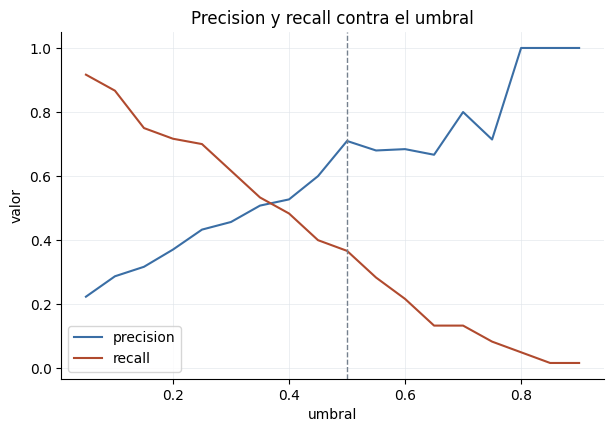

In [11]:
umbrales = np.arange(0.05, 0.91, 0.05)
precisiones = []
recalls = []

for umbral in umbrales:
    pred_u = (prob >= umbral).astype(int)
    tp = ((pred_u == 1) & (y_test == 1)).sum()
    fp = ((pred_u == 1) & (y_test == 0)).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    precisiones.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(umbrales, precisiones, color=AZUL, label="precision")
ax.plot(umbrales, recalls, color=ROJO, label="recall")
ax.axvline(0.5, color=GRIS, ls="--", lw=1)
ax.set_xlabel("umbral")
ax.set_ylabel("valor")
ax.set_title("Precision y recall contra el umbral")
ax.legend()
eje_limpio(ax)
plt.show()

# Verificación (descomentar):
assert len(precisiones) == len(recalls) == len(umbrales) == 18

### Ejercicio 9 (0.20): AUC por pares

AUC sin fórmula, como en la sesión: tomar 5,000 canceladores al azar y 5,000 no canceladores al azar (con `rng_auc.choice`, en ese orden), y medir en qué fracción de los pares el cancelador recibió mayor probabilidad. Comparar contra `roc_auc_score`.

In [12]:
from sklearn.metrics import roc_auc_score

rng_auc = np.random.default_rng(7)

pos = prob[y_test.values == 1]   # probabilidades de los que cancelaron
neg = prob[y_test.values == 0]   # probabilidades de los que se quedaron
# luego, exactamente en este orden:
p_azar = rng_auc.choice(pos, 5000)
n_azar = rng_auc.choice(neg, 5000)
auc_pares = (p_azar > n_azar).mean()     # fracción de pares donde el cancelador tuvo mayor probabilidad
auc_sklearn = roc_auc_score(y_test, prob)

print("AUC por pares:", round(auc_pares, 3))
print("AUC sklearn:", round(auc_sklearn, 3))

# Verificación (descomentar):
assert round(auc_pares, 3) == 0.821
assert round(auc_sklearn, 3) == 0.822

AUC por pares: 0.821
AUC sklearn: 0.822


### Ejercicio 10 (0.20): ¿dice la verdad?

Agrupar las probabilidades del test en cajones con `pd.cut` (bordes [0, 0.2, 0.4, 0.6, 0.8, 1.0]) y construir la tabla de calibración: por cajón, el promedio de lo que el modelo dijo, la fracción que de verdad canceló y el número de clientes.

In [15]:
grupos = pd.cut(prob, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

calib = pd.DataFrame({"dijo": prob, "real": y_test.values}).groupby(grupos, observed=False).agg(
    dijo=("dijo", "mean"),
    real=("real", "mean"),
    clientes=("real", "size"),
).reset_index(drop=True)
calib.round(2)

# Verificación (descomentar):
assert calib["clientes"].tolist() == [244, 61, 36, 16, 3]

## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** Una llamada de retención cuesta Q25; un cliente que se va sin aviso cuesta Q1,500. Con la tabla del ejercicio 7, ¿qué umbral conviene y por qué? (Basta comparar el costo total de dos o tres umbrales.)

**(b)** El gerente quiere presentar el modelo diciendo "acierta el 87% de las veces". Con los números de los ejercicios 4 y 6, explicar por qué ese argumento es débil y proponer el argumento honesto.

_(Responder editando esta celda)_

**Respuesta (a):** Con un umbral de **0.5**, se generan 31 alertas y se detecta al 37% de los clientes que realmente cancelarían. Eso significa que aproximadamente **38 clientes se perderían sin recibir aviso**. El costo sería de **Q57,775**. Con un umbral de **0.2**, se generan 116 alertas y se detecta al 72% de los clientes que podrían cancelar. En este caso, se escaparían aproximadamente **17 clientes**, dando un costo total de **Q28,400**. Con un umbral de **0.35**, se generan 63 alertas y se detecta al 53% de los posibles canceladores. Aproximadamente **28 clientes se perderían**, con un costo de **Q43,575**. Por lo tanto, el umbral de **0.2** resulta en el menor costo. Aunque genera más alertas, una llamada cuesta solo **Q25**, mientras que perder un cliente cuesta aproximadamente **Q1,500**. Por eso, en este caso conviene hacer más llamadas para tratar de evitar que se pierdan clientes.


**Respuesta (b):** El "87% de aciertos" (accuracy) es un argumento débil porque el modelo perezoso que le dice "nadie cancela" a todo el mundo ya acierta el 83.3% (ejercicio 4): la diferencia real que aporta el modelo es de apenas ~3.6 puntos, casi toda ganada en los clientes fáciles que de todas formas no iban a cancelar. El argumento honesto usa precision y recall (ejercicio 6): de las 31 alertas que dispara con umbral 0.5, el 71% son canceladores de verdad (precision), y de todos los que efectivamente cancelan, alcanza a avisar al 37% (recall). Es decir, el modelo sí identifica clientes de riesgo con bastante confianza, pero todavía deja pasar a la mayoría de los que se van sin aviso.

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Un uso que se le dio a AI fue para tener un mejor estilo en los prints. Temas de realizar las tablas, poder poner de manera mas ordenada los datos relacionandolo con que es ese dato que se está imprimiendo y también el tema de redondear los decimales. Básicamente, dejar más presentable la información para un mejor entendimiento.

- Se utilizó como apoyo para ordenar y realizar la gráfica, para asi entender bien como armarla de forma correcta.

- Se consultaron ciertos calculos o formas de realizar ciertos calculos. Tanto formulas específicas que no estaban explicitamente en la presentación, asi como algunas formas de calcular de manera sencilla los datos aprovechando el uso de las librerias y el uso de python. Básicamente facilitar el transpasar la formula y el calculo a el lenguaje de programación. 